<a href="https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/GN_integral_math_verification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GN Model — Eq. (G.4) Mathematical Verification

This notebook adds **formula-level verification** to the existing paper-curve validation.

The target is the Poggiolini **GN-model reference formula (GNRF), Eq. (G.4)**, not a closed-form `asinh` approximation. The verification is intentionally split into:

1. **Equation-to-code residual** — two algebraically equivalent implementations of the single-span term.
2. **Analytical limits** — $\Delta\beta\to0$, $N_s=1$, and coherent limit $N_s^2$.
3. **Cubic power scaling** — $G_{NLI}\propto P^3$.
4. **Unit conversion** — $\alpha_{dB}\to\alpha_{field}$ and $D\to\beta_2$.
5. **Numerical integration convergence** — Sobol-QMC sample count versus a high-order reference.

This is different from Fig.1/Fig.8/Fig.9 reproduction error: a paper-curve MAPE can include digitization and scenario-convention differences, while equation residual should be near machine precision.

In [1]:
"""Direct numerical helpers for the Poggiolini GN-model reference formula (GNRF).

Conventions
-----------
- Frequency: THz (= 1/ps)
- beta2: ps^2/km
- distance: km
- gamma: 1/(W km)
- alpha_db_per_km: conventional POWER attenuation in dB/km
- internally alpha_field = alpha_db_per_km * ln(10) / 20, so field ~ exp(-alpha z)
- channel power / PSD are dual-polarization totals; GNRF prefactor = 16/27
"""
from __future__ import annotations
import math
import numpy as np
from scipy.stats import qmc

C_NM_PER_PS = 299792.458
DP_GN_COEFF = 16.0 / 27.0


def alpha_field_from_db(alpha_db_per_km: float) -> float:
    return float(alpha_db_per_km) * math.log(10.0) / 20.0


def beta2_from_D(D_ps_nm_km: float, wavelength_nm: float = 1550.0) -> float:
    """Convert D [ps/(nm km)] to beta2 [ps^2/km]."""
    return -float(D_ps_nm_km) * float(wavelength_nm) ** 2 / (2.0 * math.pi * C_NM_PER_PS)


def phase_mismatch_beta2(f1_THz, f2_THz, f_THz, beta2_ps2_km):
    f1 = np.asarray(f1_THz, dtype=float)
    f2 = np.asarray(f2_THz, dtype=float)
    f = np.asarray(f_THz, dtype=float)
    return 4.0 * np.pi**2 * beta2_ps2_km * (f1 - f) * (f2 - f)


def effective_length(alpha_field_per_km: float, span_km: float) -> float:
    a = float(alpha_field_per_km)
    L = float(span_km)
    if abs(a) < 1e-15:
        return L
    return (1.0 - math.exp(-2.0 * a * L)) / (2.0 * a)


def span_efficiency_complex(delta_beta_per_km, alpha_field_per_km: float, span_km: float):
    """Literal Eq.-form magnitude squared of the single-span z integral."""
    q = np.asarray(delta_beta_per_km, dtype=float)
    a = float(alpha_field_per_km)
    L = float(span_km)
    h = (1.0 - np.exp((-2.0 * a + 1j * q) * L)) / (2.0 * a - 1j * q)
    return np.abs(h) ** 2


def span_efficiency_stable(delta_beta_per_km, alpha_field_per_km: float, span_km: float):
    """Algebraically equivalent real-valued stable form."""
    q = np.asarray(delta_beta_per_km, dtype=float)
    a = float(alpha_field_per_km)
    L = float(span_km)
    e = math.exp(-2.0 * a * L)
    return (1.0 + e**2 - 2.0 * e * np.cos(q * L)) / ((2.0 * a) ** 2 + q**2)


def phased_array_factor(delta_beta_per_km, span_km: float, n_spans: int):
    q = np.asarray(delta_beta_per_km, dtype=float)
    L = float(span_km)
    N = int(n_spans)
    x = q * L / 2.0
    den = np.sin(x)
    out = np.empty_like(x, dtype=float) if np.ndim(x) else None
    if np.ndim(x) == 0:
        if abs(float(den)) < 1e-12:
            return float(N * N)
        return float((math.sin(N * float(x)) / float(den)) ** 2)
    mask = np.abs(den) < 1e-12
    out[mask] = float(N * N)
    out[~mask] = (np.sin(N * x[~mask]) / den[~mask]) ** 2
    return out


def gn_kernel(delta_beta_per_km, alpha_field_per_km: float, span_km: float, n_spans: int):
    return span_efficiency_stable(delta_beta_per_km, alpha_field_per_km, span_km) * phased_array_factor(
        delta_beta_per_km, span_km, n_spans
    )


def rectangular_psd(power_W: float, bandwidth_THz: float) -> float:
    return float(power_W) / float(bandwidth_THz)


def gn_integrand_rectangular_point(
    f1_THz: float,
    f2_THz: float,
    f_THz: float,
    power_W: float,
    bandwidth_THz: float,
    beta2_ps2_km: float,
    gamma_W_inv_km: float,
    alpha_field_per_km: float,
    span_km: float,
    n_spans: int,
) -> float:
    """Pointwise integrand for a single rectangular channel.

    Returns 0 if f1, f2, or f3=f1+f2-f lies outside the rectangular channel.
    The remaining df1 df2 integration is NOT performed here.
    """
    B = float(bandwidth_THz)
    f3 = f1_THz + f2_THz - f_THz
    if max(abs(f1_THz), abs(f2_THz), abs(f3)) > B / 2.0:
        return 0.0
    G = rectangular_psd(power_W, B)
    q = phase_mismatch_beta2(f1_THz, f2_THz, f_THz, beta2_ps2_km)
    K = gn_kernel(q, alpha_field_per_km, span_km, n_spans)
    return float(DP_GN_COEFF * gamma_W_inv_km**2 * G**3 * K)


def gn_psd_center_single_rect_qmc(
    power_W: float = 1e-3,
    baud_GBd: float = 32.0,
    alpha_db_per_km: float = 0.2,
    D_ps_nm_km: float = 17.0,
    wavelength_nm: float = 1550.0,
    gamma_W_inv_km: float = 1.3,
    span_km: float = 80.0,
    n_spans: int = 10,
    sobol_power: int = 18,
    seed: int = 1,
) -> float:
    """2-D Sobol evaluation of G_NLI(f=0) for one rectangular channel.

    This is a compact numerical-convergence test of the GNRF double integral.
    Frequencies are integrated in THz, so the returned PSD unit is W/THz.
    """
    B = baud_GBd / 1000.0
    alpha = alpha_field_from_db(alpha_db_per_km)
    beta2 = beta2_from_D(D_ps_nm_km, wavelength_nm)
    sob = qmc.Sobol(d=2, scramble=True, seed=seed)
    u = sob.random_base2(int(sobol_power))
    f1 = (u[:, 0] - 0.5) * B
    f2 = (u[:, 1] - 0.5) * B
    f3 = f1 + f2
    valid = np.abs(f3) <= B / 2.0
    q = phase_mismatch_beta2(f1, f2, 0.0, beta2)
    K = gn_kernel(q, alpha, span_km, n_spans)
    G = power_W / B
    integrand = DP_GN_COEFF * gamma_W_inv_km**2 * G**3 * K * valid
    return float(np.mean(integrand) * B**2)


def relative_error_pct(calculated, reference) -> float:
    return float(abs(calculated - reference) / abs(reference) * 100.0)


def mathematical_self_test() -> dict:
    """Return core equation/limit/scaling checks for a reproducible example."""
    alpha = alpha_field_from_db(0.2)
    beta2 = beta2_from_D(17.0, 1550.0)
    L = 80.0
    N = 10
    Leff = effective_length(alpha, L)

    # Literal-complex vs algebraically stable single-span factor.
    q_test = np.array([-0.4, -0.1, 0.0, 0.07, 0.25])
    hc = span_efficiency_complex(q_test, alpha, L)
    hs = span_efficiency_stable(q_test, alpha, L)
    eq_residual = np.max(np.abs(hc - hs) / np.maximum(np.abs(hc), 1e-300)) * 100.0

    # delta-beta -> 0 limits.
    span0 = float(span_efficiency_stable(0.0, alpha, L))
    phase0 = phased_array_factor(0.0, L, N)
    span_limit_err = relative_error_pct(span0, Leff**2)
    phase_limit_err = relative_error_pct(phase0, N**2)

    # Cubic power scaling at a nonzero phase-mismatch point.
    kwargs = dict(
        f1_THz=0.016, f2_THz=-0.016, f_THz=0.0, bandwidth_THz=0.032,
        beta2_ps2_km=beta2, gamma_W_inv_km=1.3,
        alpha_field_per_km=alpha, span_km=L, n_spans=N,
    )
    i1 = gn_integrand_rectangular_point(power_W=1e-3, **kwargs)
    i2 = gn_integrand_rectangular_point(power_W=2e-3, **kwargs)
    scaling_ratio = i2 / i1
    scaling_err = relative_error_pct(scaling_ratio, 8.0)

    return {
        'alpha_field_1_per_km': alpha,
        'beta2_ps2_per_km': beta2,
        'Leff_km': Leff,
        'equation_residual_pct': eq_residual,
        'span_limit_error_pct': span_limit_err,
        'phase_limit_error_pct': phase_limit_err,
        'power_cubic_ratio': scaling_ratio,
        'power_cubic_error_pct': scaling_err,
    }


print('GNRF helper functions loaded.')

GNRF helper functions loaded.


## 1. Reference equations used by the code

For $\beta_3=0$:

$$\Delta\beta = 4\pi^2\beta_2(f_1-f)(f_2-f)$$

$$G_{NLI}(f)=\frac{16}{27}\gamma^2\iint G_{Tx}(f_1)G_{Tx}(f_2)G_{Tx}(f_1+f_2-f)\,K\,df_1df_2$$

with

$$K=\left|\frac{1-e^{(-2\alpha+j\Delta\beta)L_s}}{2\alpha-j\Delta\beta}\right|^2
\left[\frac{\sin(N_s\Delta\beta L_s/2)}{\sin(\Delta\beta L_s/2)}\right]^2.$$

Conventions in this notebook:

- $\alpha$ is **field attenuation**: $\alpha=\alpha_{dB}\ln(10)/20$.
- $D$ is converted by $\beta_2=-D\lambda^2/(2\pi c)$.
- Frequency is THz (= 1/ps), $\beta_2$ is ps$^2$/km, distance is km.
- Total dual-polarization channel power is used with the $16/27$ prefactor.

In [2]:
import pandas as pd, numpy as np, math
res = mathematical_self_test()
df = pd.DataFrame([
    ['alpha conversion', res['alpha_field_1_per_km'], np.nan, '1/km'],
    ['D -> beta2 conversion', res['beta2_ps2_per_km'], np.nan, 'ps^2/km'],
    ['effective length', res['Leff_km'], np.nan, 'km'],
    ['equation residual', res['equation_residual_pct'], 1e-9, '%'],
    ['Delta-beta -> 0 span limit error', res['span_limit_error_pct'], 1e-9, '%'],
    ['Delta-beta -> 0 phased-array limit error', res['phase_limit_error_pct'], 1e-9, '%'],
    ['P^3 scaling ratio', res['power_cubic_ratio'], 8.0, 'ratio'],
    ['P^3 scaling error', res['power_cubic_error_pct'], 1e-9, '%'],
], columns=['check','calculated','reference_or_tolerance','unit'])
display(df)


,check,calculated,reference_or_tolerance,unit
0,alpha conversion,2.302585e-02,NaN,1/km
1,D -> beta2 conversion,-2.168262e+01,NaN,ps^2/km
2,effective length,2.116927e+01,NaN,km
3,equation residual,3.513500e-14,1.000000e-09,%
4,Delta-beta -> 0 span limit error,1.268435e-14,1.000000e-09,%
5,Delta-beta -> 0 phased-array limit error,0.000000e+00,1.000000e-09,%
6,P^3 scaling ratio,8.000000e+00,8.000000e+00,ratio
7,P^3 scaling error,0.000000e+00,1.000000e-09,%


### Interpretation

For a correct implementation, the **equation residual** and the analytical-limit residuals should be essentially zero, subject only to floating-point roundoff. These tests verify the **mathematical implementation**, not whether the GN approximation itself matches split-step simulation/EGN.

## 2. Hand-calculation example — easy singular-limit check

Use this example before attempting the full 2-D integral.

Assume:

- power attenuation $\alpha_{dB}=0.20$ dB/km
- $D=17$ ps/(nm·km)
- $\lambda=1550$ nm
- $L_s=80$ km
- $N_s=10$
- $\gamma=1.3$ 1/(W·km)
- one rectangular 32-GBd channel
- $P=1$ mW total DP power
- choose $f=f_1=f_2=0$, therefore $\Delta\beta=0$

### Step A — loss conversion

$$\alpha=0.2\frac{\ln 10}{20}=0.02302585\ \mathrm{km^{-1}}$$

### Step B — dispersion conversion

$$\beta_2=-\frac{D\lambda^2}{2\pi c}\approx-21.6826\ \mathrm{ps^2/km}$$

### Step C — effective length

$$L_{eff}=\frac{1-e^{-2\alpha L_s}}{2\alpha}\approx21.1693\ \mathrm{km}$$

At $\Delta\beta=0$:

$$H_{span}=L_{eff}^2\approx448.1382\ \mathrm{km^2}$$

and

$$H_{coh}=N_s^2=100.$$

Therefore

$$K(0)=H_{span}H_{coh}\approx44813.82\ \mathrm{km^2}.$$

If you round $L_{eff}$ by hand to **21.17 km**, your hand value is

$$H_{span,hand}=21.17^2=448.1689,$$

so the hand-vs-code error is

$$\epsilon=\frac{|448.1689-448.1382|}{448.1382}\times100\approx0.00685\%.$$

That small nonzero error is **rounding error**, not a GN-model error.

In [3]:
# Reproduce the hand-calculation example numerically
alpha = alpha_field_from_db(0.2)
beta2 = beta2_from_D(17.0, 1550.0)
Leff = effective_length(alpha, 80.0)
Hspan_code = Leff**2
Hcoh_code = phased_array_factor(0.0, 80.0, 10)
K_code = Hspan_code * Hcoh_code

Leff_hand = 21.17
Hspan_hand = Leff_hand**2
K_hand = Hspan_hand * 100

hand = pd.DataFrame({
    'quantity':['alpha_field','beta2','Leff','Hspan(delta_beta=0)','Hcoh(delta_beta=0)','K(delta_beta=0)'],
    'code':[alpha,beta2,Leff,Hspan_code,Hcoh_code,K_code],
    'hand_example':[0.02303,-21.68,21.17,Hspan_hand,100,K_hand],
})
hand['abs_error_pct'] = np.abs(hand.hand_example-hand.code)/np.maximum(np.abs(hand.code),1e-300)*100
display(hand)
print('Recommended hand-check error to quote: Hspan = %.6f %%' % (abs(Hspan_hand-Hspan_code)/Hspan_code*100))


,quantity,code,hand_example,abs_error_pct
0,alpha_field,0.023026,0.02303,0.018019
1,beta2,-21.682619,-21.68000,0.012081
2,Leff,21.169275,21.17000,0.003425
3,Hspan(delta_beta=0),448.138199,448.16890,0.006851
4,Hcoh(delta_beta=0),100.000000,100.00000,0.000000
5,K(delta_beta=0),44813.819924,44816.89000,0.006851


Recommended hand-check error to quote: Hspan = 0.006851 %


## 3. Non-zero phase-mismatch hand check

A second check avoids the $0/0$ coherent-limit point. Choose:

- $f=0$
- $f_1=+16$ GHz = 0.016 THz
- $f_2=-16$ GHz = -0.016 THz

For the same fiber/link parameters:

$$\Delta\beta=4\pi^2\beta_2(0.016)(-0.016)\approx0.219135\ \mathrm{km^{-1}}.$$

Then evaluate

$$H_{span}=\frac{1+e^{-4\alpha L}-2e^{-2\alpha L}\cos(\Delta\beta L)}{(2\alpha)^2+\Delta\beta^2}$$

and

$$H_{coh}=\left[\frac{\sin(N_s\Delta\beta L/2)}{\sin(\Delta\beta L/2)}\right]^2.$$

The code values below are the targets for your calculator calculation.

In [4]:
q = float(phase_mismatch_beta2(0.016,-0.016,0.0,beta2))
Hs = float(span_efficiency_stable(q,alpha,80.0))
Hp = float(phased_array_factor(q,80.0,10))
K = Hs*Hp
print(f'delta_beta = {q:.12f} 1/km')
print(f'H_span     = {Hs:.12f} km^2')
print(f'H_coh      = {Hp:.12f}')
print(f'K          = {K:.12f} km^2')


delta_beta = 0.219134848791 1/km
H_span     = 19.706554906548 km^2
H_coh      = 0.248967964279
K          = 4.906300858043 km^2


### How to calculate your own error

If your calculator gives, for example, $H_{span,hand}=19.71$ while the code gives $19.7065549$:

$$\epsilon_{Hspan}=\frac{|19.71-19.7065549|}{19.7065549}\times100.$$

Always compare **the same intermediate quantity** first. Do not compare your single-point kernel calculation directly with the final integrated $G_{NLI}$ because the final result also includes the full $f_1,f_2$ integration.

## 4. $P^3$ scaling verification

Because the GNRF integrand contains three transmit PSD factors, multiplying every channel power by $a$ must produce

$$G_{NLI}(aP)=a^3G_{NLI}(P).$$

For $a=2$, the exact ratio must be 8. This is a very strong implementation check because it catches power/PSD convention errors.

In [5]:
kw=dict(f1_THz=0.016,f2_THz=-0.016,f_THz=0.0,bandwidth_THz=0.032,
        beta2_ps2_km=beta2,gamma_W_inv_km=1.3,alpha_field_per_km=alpha,span_km=80,n_spans=10)
I1=gn_integrand_rectangular_point(power_W=1e-3,**kw)
I2=gn_integrand_rectangular_point(power_W=2e-3,**kw)
ratio=I2/I1
print('I(1 mW) =',I1)
print('I(2 mW) =',I2)
print('ratio    =',ratio)
print('error vs 8 = %.3e %%'%relative_error_pct(ratio,8.0))


I(1 mW) = 0.00014995023962116507
I(2 mW) = 0.0011996019169693206
ratio    = 8.0
error vs 8 = 0.000e+00 %


## 5. Numerical integration convergence

This separates **equation correctness** from **numerical integration error**. We evaluate the 2-D GNRF integral at the CUT center for one rectangular 32-GBd channel and increase Sobol sample count. Four independent scrambled Sobol runs are averaged at each order.

The highest-order result is used only as a **numerical reference**, not as a paper-fitting target.

,sobol_power,samples,G_NLI_center_W_per_THz,standard_error,error_vs_2^20_pct
0,12,4096,0.000127,1.966257e-07,0.138665
1,14,16384,0.000127,7.106921e-08,0.044737
2,16,65536,0.000127,9.561416e-09,0.003089
3,18,262144,0.000127,3.148782e-09,0.001540
4,20,1048576,0.000127,2.020674e-09,0.000000


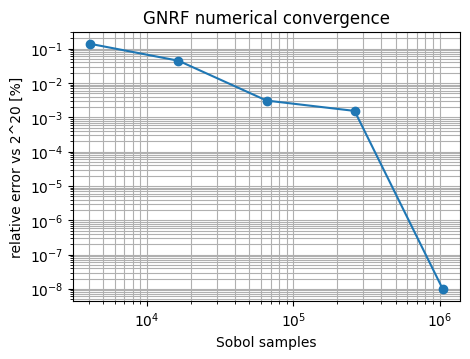

In [6]:
from scipy.stats import qmc
rows=[]
for m in [12,14,16,18,20]:
    vals=np.array([gn_psd_center_single_rect_qmc(sobol_power=m,seed=s) for s in range(4)])
    rows.append([m,2**m,vals.mean(),vals.std(ddof=1)/np.sqrt(len(vals))])
conv=pd.DataFrame(rows,columns=['sobol_power','samples','G_NLI_center_W_per_THz','standard_error'])
ref=conv.iloc[-1]['G_NLI_center_W_per_THz']
conv['error_vs_2^20_pct']=np.abs(conv.G_NLI_center_W_per_THz-ref)/abs(ref)*100
display(conv)

import matplotlib.pyplot as plt
plt.figure(figsize=(5,3.5))
plt.loglog(conv.samples, np.maximum(conv['error_vs_2^20_pct'],1e-8),'o-')
plt.xlabel('Sobol samples')
plt.ylabel('relative error vs 2^20 [%]')
plt.grid(True,which='both')
plt.title('GNRF numerical convergence')
plt.show()


## 6. Recommended reporting format

Report the three errors separately:

| Layer | Recommended metric | Meaning |
|---|---:|---|
| Formula implementation | equation residual | Is the coded kernel algebraically Eq. (G.4)? |
| Numerical integration | convergence error | Is the double integral sufficiently converged? |
| Paper reproduction | Fig.1/8/9 MAPE | Are paper scenario conventions/digitized GN curves reproduced? |

A strong conclusion is therefore of the form:

> The Eq. (G.4) kernel implementation agrees with its algebraically equivalent reference to floating-point precision; analytical limit and $P^3$ scaling tests pass; Sobol integration converges to within the reported numerical tolerance. Residual Paper-vs-Code MAPE should therefore be interpreted primarily as scenario/digitization/model-convention difference rather than an equation-coding error.